In [ ]:
import os
from pathlib import Path

def _find_project_root():
    for cand in (Path.cwd(), *Path.cwd().parents):
        if (cand / 'data').is_dir() and (cand / 'notebooks').is_dir():
            return cand
    return Path.cwd()

os.chdir(os.environ.get('ML_IDS_ROOT') or _find_project_root())
print('Project root:', os.getcwd())

Project root: /home/user/22056253/ML-IDS


In [2]:
# ─────────────────────────────────────────────────────────────────────
# CELL 0 — Load hybrid features and define calibration utilities
#
# Loads the FULL 56-feature hybrid training set (all ~18.4 M partially
# SMOTE-oversampled rows — still ~3000:1 class-imbalanced), full val and
# test sets, and the label encoder produced by feature_engineering.ipynb.
# Shape assertions guard against row-order misalignment between the
# features/ and processed/ directories which were produced by separate
# pipeline steps.
#
# Two shared utilities are defined here and reused by every model cell:
#   predict_calibrated() — applies per-class probability thresholds and
#     falls back to argmax if no class clears its threshold.
#   calibrate_thresholds() — grid-searches thresholds on [0.04, 0.96] in
#     steps of 0.02 to maximise per-class F1 on the validation set.
# ─────────────────────────────────────────────────────────────────────
import numpy as np
import joblib
import os
import builtins, functools

# Force-flush all print output so VS Code / Jupyter captures it immediately.
# Without this, output from long-running cells (RF, XGB training) can be
# buffered and lost if the display stream closes before the cell ends.
builtins.print = functools.partial(builtins.print, flush=True)

X_train = np.load('data/features/X_train_hybrid.npy')
y_train = np.load('data/processed/y_train.npy')
X_val   = np.load('data/features/X_val_hybrid.npy')
y_val   = np.load('data/processed/y_val.npy')
X_test  = np.load('data/features/X_test_hybrid.npy')
y_test  = np.load('data/processed/y_test.npy')
le      = joblib.load('models/label_encoder.pkl')

# Guard against cross-pipeline row-order misalignment (features/ vs processed/)
assert X_val.shape[0]  == y_val.shape[0],  f'X_val/y_val row mismatch: {X_val.shape[0]} vs {y_val.shape[0]}'
assert X_test.shape[0] == y_test.shape[0], f'X_test/y_test row mismatch: {X_test.shape[0]} vs {y_test.shape[0]}'
assert X_train.shape[0] == y_train.shape[0], f'X_train/y_train row mismatch: {X_train.shape[0]} vs {y_train.shape[0]}'

print(f'X_train: {X_train.shape}')
print(f'X_val:   {X_val.shape}')
print(f'X_test:  {X_test.shape}')
print(f'Classes: {list(le.classes_)}')


# ── Shared calibration utilities (defined once, used in every model cell) ─
def predict_calibrated(proba, thresholds):
    """Pick the highest-prob class that exceeds its threshold.
    Falls back to unconstrained argmax if no class qualifies."""
    masked = np.where(proba >= thresholds, proba, -1.0)
    no_qualify = np.all(masked < 0, axis=1)
    result = np.argmax(masked, axis=1)
    result[no_qualify] = np.argmax(proba[no_qualify], axis=1)
    return result


def calibrate_thresholds(y_true, val_proba, n_cls):
    """Grid-search per-class F1-maximising threshold on the validation set."""
    from sklearn.metrics import f1_score
    # linspace avoids float-accumulation drift in np.arange.
    # Bounds 0.04–0.96 with 47 steps give step=0.02; 0.04+23*0.02=0.50 is always in the grid.
    grid = np.linspace(0.04, 0.96, 47)
    thresholds = np.full(n_cls, 0.5)
    print(f"\n{'Class':<30} {'Threshold':>10}  {'Val F1':>8}")
    print('─' * 52)
    for c in range(n_cls):
        y_bin = (y_true == c).astype(int)
        best_f1, best_t = 0.0, 0.5
        for t in grid:
            f1 = f1_score(y_bin, (val_proba[:, c] >= t).astype(int), zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        thresholds[c] = best_t
        marker = ' ◄ raised' if best_t > 0.5 else (' ◄ lowered' if best_t < 0.45 else '')
        print(f'  {le.classes_[c]:<28} {best_t:>10.2f}  {best_f1:>8.3f}{marker}')
    return thresholds

X_train: (18412356, 56)
X_val:   (2434941, 56)
X_test:  (2434942, 56)
Classes: ['Benign', 'Bot', 'Brute Force -Web', 'Brute Force -XSS', 'DDOS attack-HOIC', 'DDOS attack-LOIC-UDP', 'DDoS attacks-LOIC-HTTP', 'DoS attacks-GoldenEye', 'DoS attacks-Hulk', 'DoS attacks-SlowHTTPTest', 'DoS attacks-Slowloris', 'FTP-BruteForce', 'Infilteration', 'SQL Injection', 'SSH-Bruteforce']


In [3]:
# ─────────────────────────────────────────────────────────────────────
# CELL 1 — Train Random Forest
#
# Trains a 300-tree Random Forest on the full ~18 M-row hybrid training set.
# Key hyperparameters:
#   n_estimators=300  — enough trees for a stable majority vote.
#   max_depth=35      — depth capped so the forest fits in RAM on the full
#                       ~18 M-row SMOTE set (unbounded needs 100+ GB and a
#                       ~31 GB model); min_samples_leaf=2 regularises leaves.
#   max_samples=0.5   — each tree bootstraps 50% of rows (halves tree cost).
#   class_weight="balanced" — upweights minority attack classes so the
#                             forest does not collapse to predicting Benign.
# Saved to models/random_forest.pkl.
# ─────────────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
import joblib, os

# Reuse the saved model on a Restart & Run All instead of retraining (~27 min).
# Set FORCE_RETRAIN = True to train from scratch and overwrite the checkpoint.
FORCE_RETRAIN = False
if not FORCE_RETRAIN and os.path.exists('models/random_forest.pkl'):
    print('Loading cached Random Forest from disk (set FORCE_RETRAIN=True to retrain)...')
    rf = joblib.load('models/random_forest.pkl')
    print('Loaded.')
else:
    print("Training Random Forest...")
    rf = RandomForestClassifier(
        n_estimators=300,       # more trees = more stable vote (raised from 200 for capacity)
        # ── Memory cap for the full ~18 M-row SMOTE set ──────────────────────
        # Unbounded depth on 18 M rows needs ~100+ GB RAM and yields a ~31 GB model.
        # Capping keeps it to ~20-40 GB -> fits cpu-16c-std (128 GB) with headroom.
        # To restore the original unbounded forest: set max_depth=None, delete the
        # max_samples line, and run on cpu-16c-mem (256 GB).
        max_depth=35,
        max_samples=0.5,        # each tree bootstraps 50% of rows — halves per-tree cost
        min_samples_leaf=2,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42,
        verbose=1
    )
    rf.fit(X_train, y_train)
    joblib.dump(rf, 'models/random_forest.pkl')
    print("Random Forest saved!")


Loading cached Random Forest from disk (set FORCE_RETRAIN=True to retrain)...
Loaded.


[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.


[Parallel(n_jobs=32)]: Done 136 tasks      | elapsed:    7.0s


=== Random Forest Results ===


[Parallel(n_jobs=32)]: Done 300 out of 300 | elapsed:   14.7s finished


                          precision    recall  f1-score   support

                  Benign       0.99      0.89      0.94   2022707
                     Bot       0.99      1.00      0.99     42929
        Brute Force -Web       0.16      0.87      0.27        91
        Brute Force -XSS       0.52      0.76      0.62        34
        DDOS attack-HOIC       1.00      1.00      1.00    102902
    DDOS attack-LOIC-UDP       0.76      0.98      0.86       259
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00     86429
   DoS attacks-GoldenEye       1.00      1.00      1.00      6226
        DoS attacks-Hulk       1.00      1.00      1.00     69287
DoS attacks-SlowHTTPTest       0.76      0.52      0.62     20984
   DoS attacks-Slowloris       0.65      0.99      0.78      1648
          FTP-BruteForce       0.72      0.88      0.79     29004
           Infilteration       0.05      0.50      0.09     24290
           SQL Injection       0.69      0.69      0.69        13
         

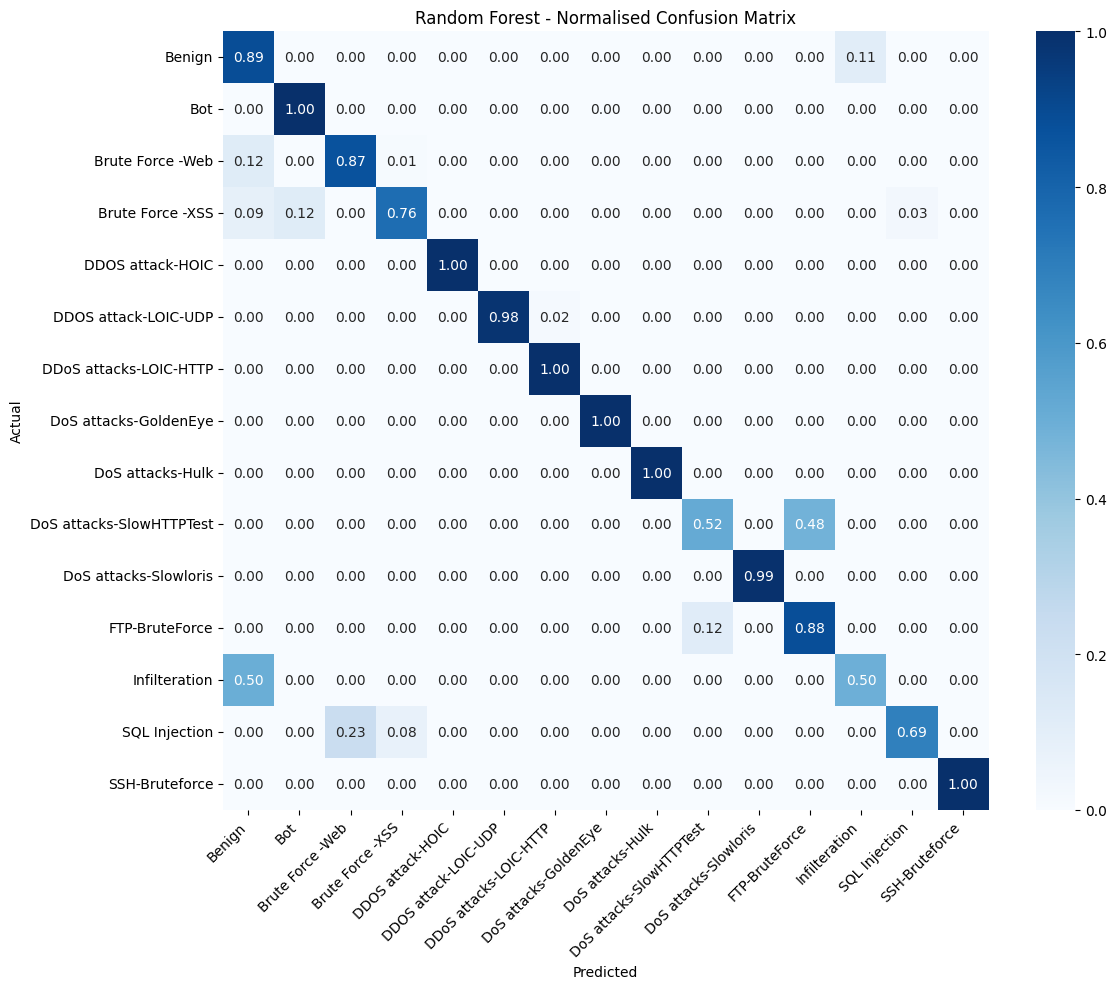

In [4]:
# ─────────────────────────────────────────────────────────────────────
# CELL 2 — Evaluate RF with uncalibrated predictions
#
# Generates predictions using the default argmax of predict_proba() and
# prints a per-class classification report and normalised confusion matrix.
# These uncalibrated numbers serve as a baseline to compare against the
# calibrated threshold results produced in cell 3.
# ─────────────────────────────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_rf = rf.predict(X_test)

print("=== Random Forest Results ===")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf, normalize='true')
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='.2f', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_,
            cmap='Blues')
plt.title('Random Forest - Normalised Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('results/rf_confusion_matrix.png')
plt.show()

In [5]:
# ─────────────────────────────────────────────────────────────────────
# CELL 3 — RF per-class probability threshold calibration
#
# Calls calibrate_thresholds() on the validation set to find the
# probability threshold for each class that maximises its val F1.
# Thresholds are saved to models/thresholds_rf.npy.
# The calibrated predictions are then evaluated on the held-out test set.
# Calibration is always tuned on val, never on test — re-tuning on test
# would constitute data leakage and overstate real-world performance.
# ─────────────────────────────────────────────────────────────────────
from sklearn.metrics import classification_report

print("Computing RF val probabilities (may take ~1 min)...")
val_proba_rf  = rf.predict_proba(X_val)

thresholds_rf = calibrate_thresholds(y_val, val_proba_rf, len(le.classes_))
np.save('models/thresholds_rf.npy', thresholds_rf)

test_proba_rf = rf.predict_proba(X_test)
y_pred_rf_cal = predict_calibrated(test_proba_rf, thresholds_rf)

print("\n=== Random Forest — Calibrated Thresholds ===")
print(classification_report(y_test, y_pred_rf_cal, target_names=le.classes_))


Computing RF val probabilities (may take ~1 min)...


[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done 136 tasks      | elapsed:    7.0s



Class                           Threshold    Val F1
────────────────────────────────────────────────────


[Parallel(n_jobs=32)]: Done 300 out of 300 | elapsed:   14.7s finished


  Benign                             0.04     0.993 ◄ lowered
  Bot                                0.94     0.994 ◄ raised
  Brute Force -Web                   0.96     0.605 ◄ raised
  Brute Force -XSS                   0.92     0.882 ◄ raised
  DDOS attack-HOIC                   0.60     1.000 ◄ raised
  DDOS attack-LOIC-UDP               0.36     0.851 ◄ lowered
  DDoS attacks-LOIC-HTTP             0.48     0.999
  DoS attacks-GoldenEye              0.46     1.000
  DoS attacks-Hulk                   0.42     1.000 ◄ lowered
  DoS attacks-SlowHTTPTest           0.44     0.700 ◄ lowered
  DoS attacks-Slowloris              0.94     0.977 ◄ raised
  FTP-BruteForce                     0.34     0.796 ◄ lowered
  Infilteration                      0.88     0.270 ◄ raised
  SQL Injection                      0.50     0.625
  SSH-Bruteforce                     0.38     1.000 ◄ lowered


[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done 136 tasks      | elapsed:    7.0s
[Parallel(n_jobs=32)]: Done 300 out of 300 | elapsed:   14.7s finished



=== Random Forest — Calibrated Thresholds ===
                          precision    recall  f1-score   support

                  Benign       0.99      0.99      0.99   2022707
                     Bot       0.99      1.00      0.99     42929
        Brute Force -Web       0.71      0.67      0.69        91
        Brute Force -XSS       0.69      0.74      0.71        34
        DDOS attack-HOIC       1.00      1.00      1.00    102902
    DDOS attack-LOIC-UDP       0.76      0.98      0.86       259
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00     86429
   DoS attacks-GoldenEye       1.00      1.00      1.00      6226
        DoS attacks-Hulk       1.00      1.00      1.00     69287
DoS attacks-SlowHTTPTest       0.76      0.52      0.62     20984
   DoS attacks-Slowloris       0.90      0.99      0.94      1648
          FTP-BruteForce       0.72      0.88      0.79     29004
           Infilteration       0.33      0.24      0.28     24290
           SQL Injection    

In [6]:
# ─────────────────────────────────────────────────────────────────────
# CELL 4 — Train XGBoost
#
# Trains an XGBoost gradient-boosted classifier for up to 8000 rounds.
# Key hyperparameters:
#   learning_rate=0.05   — conservative step size for better generalisation.
#   max_depth=6          — limits individual tree complexity.
#   subsample=0.8        — row subsampling per tree (reduces overfitting).
#   colsample_bytree=0.8 — feature subsampling per tree.
#   early_stopping_rounds=50 — halts if val mlogloss does not improve for
#                               50 consecutive rounds.
#   n_estimators=8000 — raised from 3000: at the old cap val mlogloss was
#                       still falling monotonically (early stopping never
#                       fired), i.e. the model was undertrained. 8000 lets
#                       it run until val loss genuinely plateaus.
# Uses the validation set as the eval_set so early stopping is based on
# out-of-sample loss, not training loss.
#
# Class imbalance: XGBClassifier has no `class_weight` param, so — unlike
# RF (class_weight='balanced') and the MLP (weighted CrossEntropyLoss) — it
# would otherwise ignore the ~3000:1 residual imbalance and lean toward the
# majority classes. We pass per-row `sample_weight` from compute_sample_weight
# ('balanced'), the sample-level equivalent of class_weight='balanced', so the
# gradient upweights minority attack flows to match the other supervised models.
# ─────────────────────────────────────────────────────────────────────
import xgboost as xgb
import joblib, os
from sklearn.utils.class_weight import compute_sample_weight

# Reuse the saved model on a Restart & Run All instead of retraining.
# NOTE: the original model was trained on GPU (device='cuda'); if this box has
# no GPU, retraining falls back to CPU (much slower, and may differ slightly).
# Set FORCE_RETRAIN = True to train from scratch and overwrite the checkpoint.
FORCE_RETRAIN = False
if not FORCE_RETRAIN and os.path.exists('models/xgboost.pkl'):
    print('Loading cached XGBoost from disk (set FORCE_RETRAIN=True to retrain)...')
    xgb_model = joblib.load('models/xgboost.pkl')
    print('Loaded.')
else:
    # Balanced per-row weights (inverse class frequency) — counters the residual
    # imbalance that survives SMOTE. Equivalent effect to class_weight='balanced'.
    sample_weight_train = compute_sample_weight('balanced', y_train)

    # GPU auto-detect: uses the L4/T4/A10G if present, else falls back to CPU.
    import torch
    _xgb_device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f'Training XGBoost on device: {_xgb_device}')
    xgb_model = xgb.XGBClassifier(
        n_estimators=8000,   # raised from 3000 — early stopping never fired at 3000
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        early_stopping_rounds=50,   # was 20 — too tight, stopped 474 rounds too late
        tree_method='hist',         # histogram algorithm — GPU-accelerated when device='cuda'
        device=_xgb_device,         # 'cuda' on a GPU box (~10-30x faster), else 'cpu'
        n_jobs=-1,
        random_state=42,
        verbosity=1
    )
    xgb_model.fit(
        X_train, y_train,
        sample_weight=sample_weight_train,   # balanced weighting — see cell header
        eval_set=[(X_val, y_val)],
        verbose=50
    )
    joblib.dump(xgb_model, 'models/xgboost.pkl')
    print('XGBoost saved!')


Loading cached XGBoost from disk (set FORCE_RETRAIN=True to retrain)...


/application/miniconda/25.5.1/lib/python3.13/pickle.py:1760: UserWarning: [04:13:55] WARNING: /__w/xgboost/xgboost/src/gbm/gbtree.cc:402: Changing updater from `grow_gpu_hist` to `grow_quantile_histmaker`.
  setstate(state)
/application/miniconda/25.5.1/lib/python3.13/pickle.py:1760: UserWarning: [04:13:55] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  setstate(state)
/application/miniconda/25.5.1/lib/python3.13/pickle.py:1760: UserWarning: [04:13:55] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  setstate(state)


Loaded.


=== XGBoost Results ===
                          precision    recall  f1-score   support

                  Benign       1.00      0.77      0.87   2022707
                     Bot       0.98      1.00      0.99     42929
        Brute Force -Web       0.02      0.93      0.04        91
        Brute Force -XSS       0.38      0.79      0.51        34
        DDOS attack-HOIC       1.00      1.00      1.00    102902
    DDOS attack-LOIC-UDP       0.82      0.95      0.88       259
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00     86429
   DoS attacks-GoldenEye       1.00      1.00      1.00      6226
        DoS attacks-Hulk       1.00      1.00      1.00     69287
DoS attacks-SlowHTTPTest       0.76      0.52      0.62     20984
   DoS attacks-Slowloris       0.44      1.00      0.61      1648
          FTP-BruteForce       0.72      0.88      0.79     29004
           Infilteration       0.04      0.69      0.07     24290
           SQL Injection       0.01      0.54      

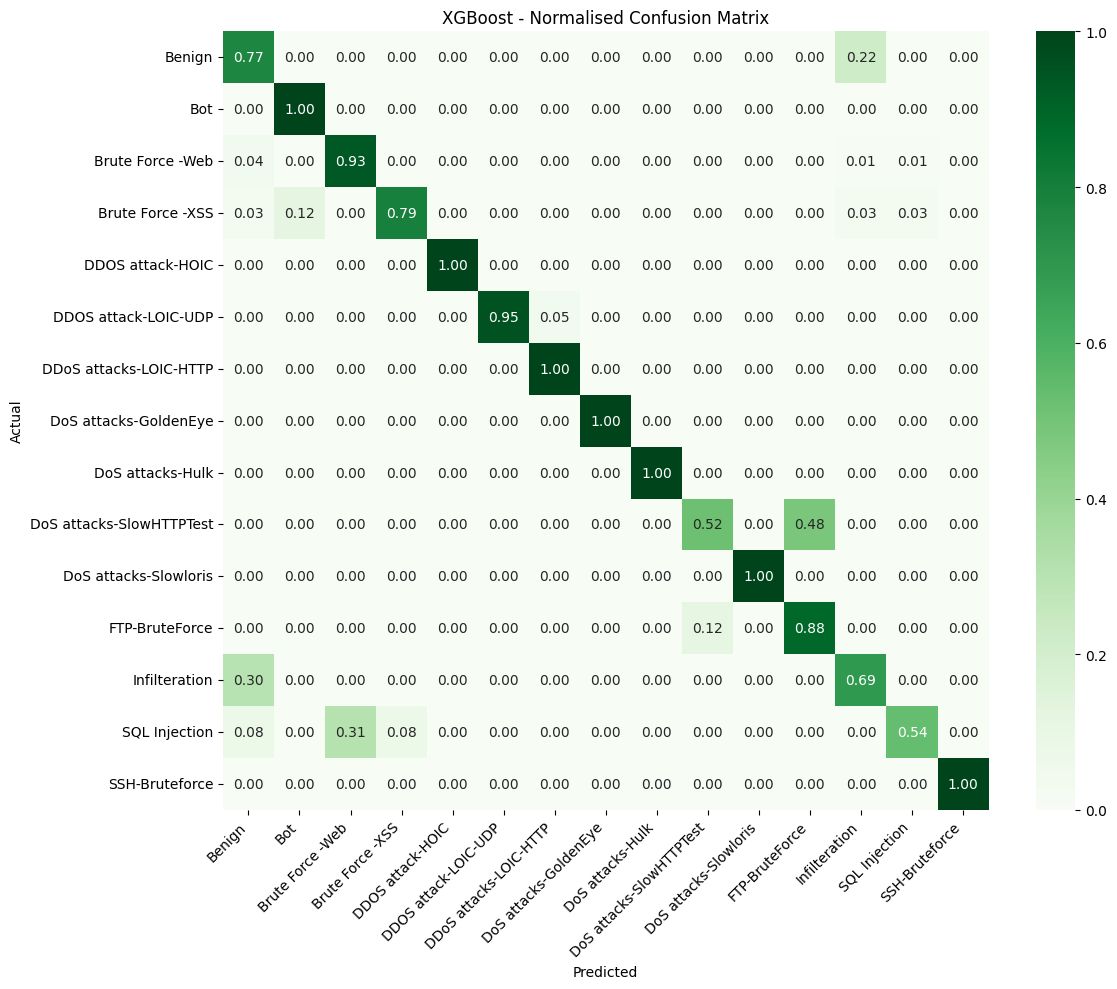

In [7]:
# ─────────────────────────────────────────────────────────────────────
# CELL 5 — Evaluate XGBoost with uncalibrated predictions
#
# Generates default argmax predictions from the trained XGBoost model and
# prints the classification report plus a normalised confusion matrix.
# Baseline for comparison with the calibrated results in cell 6.
# ─────────────────────────────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_xgb = xgb_model.predict(X_test)

print("=== XGBoost Results ===")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

# Confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb, normalize='true')
plt.figure(figsize=(12, 10))
sns.heatmap(cm_xgb, annot=True, fmt='.2f',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Greens')
plt.title('XGBoost - Normalised Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('results/xgb_confusion_matrix.png')
plt.show()

In [8]:
# ─────────────────────────────────────────────────────────────────────
# CELL 6 — XGBoost per-class probability threshold calibration
#
# Same calibration procedure as cell 3 but applied to XGBoost.
# Thresholds are saved to models/thresholds_xgb.npy.
# Calibrated test predictions are reported alongside per-class thresholds
# so it is visible which classes required raising (precision focus) or
# lowering (recall focus) their threshold.
# ─────────────────────────────────────────────────────────────────────
from sklearn.metrics import classification_report

print("Computing XGBoost val probabilities...")
val_proba_xgb  = xgb_model.predict_proba(X_val)

thresholds_xgb = calibrate_thresholds(y_val, val_proba_xgb, len(le.classes_))
np.save('models/thresholds_xgb.npy', thresholds_xgb)

test_proba_xgb = xgb_model.predict_proba(X_test)
y_pred_xgb_cal = predict_calibrated(test_proba_xgb, thresholds_xgb)

print("\n=== XGBoost — Calibrated Thresholds ===")
print(classification_report(y_test, y_pred_xgb_cal, target_names=le.classes_))


Computing XGBoost val probabilities...

Class                           Threshold    Val F1
────────────────────────────────────────────────────
  Benign                             0.04     0.993 ◄ lowered
  Bot                                0.96     0.994 ◄ raised
  Brute Force -Web                   0.96     0.182 ◄ raised
  Brute Force -XSS                   0.90     0.630 ◄ raised
  DDOS attack-HOIC                   0.78     1.000 ◄ raised
  DDOS attack-LOIC-UDP               0.66     0.866 ◄ raised
  DDoS attacks-LOIC-HTTP             0.94     0.999 ◄ raised
  DoS attacks-GoldenEye              0.36     1.000 ◄ lowered
  DoS attacks-Hulk                   0.30     1.000 ◄ lowered
  DoS attacks-SlowHTTPTest           0.44     0.700 ◄ lowered
  DoS attacks-Slowloris              0.94     0.977 ◄ raised
  FTP-BruteForce                     0.36     0.796 ◄ lowered
  Infilteration                      0.94     0.291 ◄ raised
  SQL Injection                      0.96     0.444 ◄ rai

In [9]:
# ─────────────────────────────────────────────────────────────────────
# CELL 6b — MLP architecture (definition only, no training)
#
# The MLP *class* is defined here, decoupled from the training cell below,
# so it is available after a kernel restart WITHOUT re-running the 200-epoch
# training loop. Every downstream recovery block (cells 13, 17) rebuilds the
# model from models/mlp.pth and needs this class in memory to do so.
# Architecture: 56 -> 512 -> 256 -> 128 -> num_classes (matches the checkpoint
# and inference.py). Re-run this one cell after a restart; it is instant.
# ─────────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps'  if torch.backends.mps.is_available()
    else 'cpu'
)

class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)

print(f'MLP class defined. Using device: {device}')


MLP class defined. Using device: cpu


In [10]:
# ─────────────────────────────────────────────────────────────────────
# CELL 7 — Define and train MLP
#
# Defines a 4-layer MLP: 56 → 512 → 256 → 128 → 15 classes.
# The width was doubled from an earlier narrower version (256→128→64)
# after the narrow network showed underfitting on minority classes.
# Key training choices:
#   Weighted CrossEntropyLoss — class weights from compute_class_weight
#     "balanced" ensure the loss is not dominated by Benign traffic.
#   Adam optimiser, lr=5e-4, weight_decay=1e-4 — L2 regularisation.
#   Full dataset moved to MPS device once — eliminates per-batch CPU→MPS
#     transfers that were the main training bottleneck.
#   Patience=20 early stopping on validation loss; best weights saved.
# ─────────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import os
from sklearn.utils.class_weight import compute_class_weight

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps'  if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Using device: {device}')

class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),   # wider: was 256
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),         # was 128
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),         # was 64
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)

input_dim   = X_train.shape[1]
num_classes = len(le.classes_)

# Reuse the saved weights on a Restart & Run All instead of retraining.
# Set FORCE_RETRAIN = True to train from scratch and overwrite the checkpoint.
FORCE_RETRAIN = False
if not FORCE_RETRAIN and os.path.exists('models/mlp.pth'):
    print('Loading cached MLP from disk (set FORCE_RETRAIN=True to retrain)...')
    mlp = MLP(input_dim, num_classes).to(device)
    mlp.load_state_dict(torch.load('models/mlp.pth', weights_only=True))
    mlp.eval()
    print('Loaded.')
else:
    mlp = MLP(input_dim, num_classes).to(device)

    class_weights  = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    weights_tensor = torch.FloatTensor(class_weights).to(device)
    criterion      = nn.CrossEntropyLoss(weight=weights_tensor)
    optimizer      = torch.optim.Adam(mlp.parameters(), lr=5e-4, weight_decay=1e-4)  # lr was 1e-3

    # Move full dataset to device once — eliminates per-batch CPU->device transfers
    print('Moving data to device...')
    X_train_dev = torch.from_numpy(X_train.astype(np.float32, copy=False)).to(device)
    y_train_dev = torch.from_numpy(y_train).long().to(device)
    X_val_dev   = torch.from_numpy(X_val.astype(np.float32, copy=False)).to(device)
    y_val_dev   = torch.from_numpy(y_val).long().to(device)
    n_train = X_train_dev.shape[0]
    n_val   = X_val_dev.shape[0]
    print('Data on device.')

    batch_size    = 4096
    n_batches     = (n_train + batch_size - 1) // batch_size
    n_val_batches = (n_val   + batch_size - 1) // batch_size

    best_val_loss    = float('inf')
    patience         = 20   # was 15 — wider network needs more epochs to stabilise
    patience_counter = 0

    print('Training MLP...')
    for epoch in range(200):
        mlp.train()
        perm = torch.randperm(n_train, device=device)
        train_loss = torch.tensor(0.0, device=device)
        for start in range(0, n_train, batch_size):
            idx = perm[start:start + batch_size]
            optimizer.zero_grad()
            loss = criterion(mlp(X_train_dev[idx]), y_train_dev[idx])
            loss.backward()
            optimizer.step()
            train_loss += loss.detach()

        mlp.eval()
        val_loss = torch.tensor(0.0, device=device)
        with torch.no_grad():
            for start in range(0, n_val, batch_size):
                val_loss += criterion(
                    mlp(X_val_dev[start:start + batch_size]),
                    y_val_dev[start:start + batch_size]
                )

        train_loss = train_loss.item() / n_batches
        val_loss   = val_loss.item()   / n_val_batches

        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(mlp.state_dict(), 'models/mlp.pth')
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

    print('MLP training complete!')


Using device: cpu
Loading cached MLP from disk (set FORCE_RETRAIN=True to retrain)...
Loaded.


In [11]:
# ─────────────────────────────────────────────────────────────────────
# CELL 8 — Evaluate MLP with uncalibrated predictions
#
# Reloads the best MLP checkpoint (saved by early stopping in cell 7)
# and generates argmax predictions on the test set.
# Runs inference in batches of 4096 to fit within device memory.
# Baseline uncalibrated results for comparison with cell 9.
# ─────────────────────────────────────────────────────────────────────
from sklearn.metrics import classification_report
import torch
import numpy as np

mlp.load_state_dict(torch.load('models/mlp.pth', weights_only=True))
mlp.eval()
mlp = mlp.to(device)

X_test_dev = torch.from_numpy(X_test.astype(np.float32, copy=False)).to(device)
batch_size = 4096
all_preds = []
with torch.no_grad():
    for start in range(0, len(X_test_dev), batch_size):
        preds = torch.argmax(mlp(X_test_dev[start:start + batch_size]), dim=1)
        all_preds.append(preds.cpu())

y_pred_mlp = torch.cat(all_preds).numpy()

print("=== MLP Results ===")
print(classification_report(y_test, y_pred_mlp, target_names=le.classes_))

=== MLP Results ===
                          precision    recall  f1-score   support

                  Benign       0.99      0.49      0.66   2022707
                     Bot       0.65      1.00      0.78     42929
        Brute Force -Web       0.00      0.68      0.00        91
        Brute Force -XSS       0.00      0.62      0.01        34
        DDOS attack-HOIC       0.96      1.00      0.98    102902
    DDOS attack-LOIC-UDP       0.03      1.00      0.06       259
  DDoS attacks-LOIC-HTTP       0.60      1.00      0.75     86429
   DoS attacks-GoldenEye       0.92      0.66      0.77      6226
        DoS attacks-Hulk       0.93      1.00      0.97     69287
DoS attacks-SlowHTTPTest       0.52      0.99      0.68     20984
   DoS attacks-Slowloris       0.19      1.00      0.32      1648
          FTP-BruteForce       0.98      0.33      0.49     29004
           Infilteration       0.02      0.71      0.04     24290
           SQL Injection       0.00      0.69      0.00

In [12]:
# ─────────────────────────────────────────────────────────────────────
# CELL 9 — MLP per-class probability threshold calibration
#
# Applies calibrate_thresholds() to the MLP using softmax probabilities
# (not raw logits) on the validation set.
# Thresholds saved to models/thresholds_mlp.npy.
# The MLP tends to have poorly calibrated softmax outputs (overconfident
# on majority class) so threshold calibration has the largest relative
# impact on MLP performance compared to RF and XGBoost.
# ─────────────────────────────────────────────────────────────────────
from sklearn.metrics import classification_report

print("Computing MLP val probabilities...")
mlp.eval()

X_val_t  = torch.from_numpy(X_val.astype(np.float32,  copy=False)).to(device)
X_test_t = torch.from_numpy(X_test.astype(np.float32, copy=False)).to(device)
batch_size = 4096

val_proba_mlp = []
with torch.no_grad():
    for start in range(0, len(X_val_t), batch_size):
        logits = mlp(X_val_t[start:start + batch_size])
        val_proba_mlp.append(torch.softmax(logits, dim=1).cpu().numpy())
val_proba_mlp = np.concatenate(val_proba_mlp)

thresholds_mlp = calibrate_thresholds(y_val, val_proba_mlp, len(le.classes_))
np.save('models/thresholds_mlp.npy', thresholds_mlp)

test_proba_mlp = []
with torch.no_grad():
    for start in range(0, len(X_test_t), batch_size):
        logits = mlp(X_test_t[start:start + batch_size])
        test_proba_mlp.append(torch.softmax(logits, dim=1).cpu().numpy())
test_proba_mlp = np.concatenate(test_proba_mlp)

y_pred_mlp_cal = predict_calibrated(test_proba_mlp, thresholds_mlp)

print("\n=== MLP — Calibrated Thresholds ===")
print(classification_report(y_test, y_pred_mlp_cal, target_names=le.classes_))


Computing MLP val probabilities...

Class                           Threshold    Val F1
────────────────────────────────────────────────────
  Benign                             0.04     0.983 ◄ lowered
  Bot                                0.64     0.883 ◄ raised
  Brute Force -Web                   0.96     0.424 ◄ raised
  Brute Force -XSS                   0.94     0.679 ◄ raised
  DDOS attack-HOIC                   0.96     0.990 ◄ raised
  DDOS attack-LOIC-UDP               0.94     0.836 ◄ raised
  DDoS attacks-LOIC-HTTP             0.94     0.946 ◄ raised
  DoS attacks-GoldenEye              0.50     0.778
  DoS attacks-Hulk                   0.50     0.968
  DoS attacks-SlowHTTPTest           0.50     0.680
  DoS attacks-Slowloris              0.94     0.755 ◄ raised
  FTP-BruteForce                     0.40     0.780 ◄ lowered
  Infilteration                      0.96     0.240 ◄ raised
  SQL Injection                      0.96     0.012 ◄ raised
  SSH-Bruteforce              

In [13]:
# ─────────────────────────────────────────────────────────────────────
# CELL 10 — Train Isolation Forest on benign-only traffic
#
# Fits an Isolation Forest on the benign training rows only so it learns
# the distribution of normal traffic. Flows that deviate from this
# distribution are then flagged as anomalies on the full test set.
# Contamination is set to the actual fraction of attacks in the original
# (pre-SMOTE) training data (16.93 %) so the IF decision boundary is
# calibrated to the real class ratio, not the SMOTE-balanced one.
# ─────────────────────────────────────────────────────────────────────
from sklearn.ensemble import IsolationForest
import joblib, os

# Reuse the saved detector on a Restart & Run All instead of refitting.
# Set FORCE_RETRAIN = True to fit from scratch and overwrite the checkpoint.
FORCE_RETRAIN = False
if not FORCE_RETRAIN and os.path.exists('models/isolation_forest.pkl'):
    print('Loading cached Isolation Forest from disk (set FORCE_RETRAIN=True to retrain)...')
    iso_forest = joblib.load('models/isolation_forest.pkl')
    print('Loaded.')
else:
    # Benign is class 0; fit only on benign rows so attacks are genuinely out-of-distribution
    X_train_benign = X_train[y_train == 0]
    # Use original (pre-SMOTE) labels for contamination rate.
    # SMOTE y_train is ~49% attacks; real network traffic is ~17%.
    _y_orig = np.load('data/processed/y_train_original.npy')
    contamination  = float((_y_orig != 0).mean())
    contamination  = round(min(max(contamination, 0.001), 0.5), 4)  # clamp to valid range
    print(f'Benign training rows: {X_train_benign.shape[0]}')
    print(f'Contamination (fraction of attacks in full train set): {contamination:.4f}')

    print('Training Isolation Forest...')
    iso_forest = IsolationForest(
        n_estimators=100,
        contamination=contamination,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )
    iso_forest.fit(X_train_benign)
    joblib.dump(iso_forest, 'models/isolation_forest.pkl')
    print('Isolation Forest saved!')

y_pred_iso = iso_forest.predict(X_test)
anomalies  = (y_pred_iso == -1).sum()
print(f'Anomalies detected in test set: {anomalies} out of {len(y_pred_iso)}')


Loading cached Isolation Forest from disk (set FORCE_RETRAIN=True to retrain)...
Loaded.


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    2.6s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    5.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    2.6s


Anomalies detected in test set: 424846 out of 2434942


[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    5.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.1s finished


In [14]:
# ─────────────────────────────────────────────────────────────────────
# CELL 11 — Train Autoencoder anomaly detector on benign-only traffic
#
# Trains a compact autoencoder (56→32→16→32→56) on the benign subset
# of the hybrid training data. Because the model only sees normal traffic,
# it learns to reconstruct benign flows accurately. At inference, flows
# with high per-sample MSE are flagged as attacks (anomalous inputs
# cannot be reconstructed well by a benign-trained model).
#
# This is distinct from the feature-engineering autoencoder (autoencoder.pth)
# which was trained on all 77-dim real traffic purely for feature extraction.
# This model uses the same 56-dim hybrid features as RF / XGBoost / MLP /
# Isolation Forest, making it directly comparable with other detectors.
# ─────────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import os

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Device: {device}')

# ── Architecture ────────────────────────────────────────────────────
class AEAnomaly(nn.Module):
    def __init__(self, input_dim=56):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(),
            nn.Linear(32, 16),        nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(16, 32),        nn.ReLU(),
            nn.Linear(32, input_dim), nn.Sigmoid(),
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

# Reuse the saved weights on a Restart & Run All instead of retraining (150 epochs).
# Set FORCE_RETRAIN = True to train from scratch and overwrite the checkpoint.
FORCE_RETRAIN = False
if not FORCE_RETRAIN and os.path.exists('models/autoencoder_anomaly.pth'):
    print('Loading cached Autoencoder from disk (set FORCE_RETRAIN=True to retrain)...')
    ae_model = AEAnomaly(input_dim=X_train.shape[1]).to(device)
    ae_model.load_state_dict(torch.load('models/autoencoder_anomaly.pth', weights_only=True))
    ae_model.eval()
    print('Loaded.')
else:
    # ── Move benign data to device once ─────────────────────────────────
    X_ae_train_np = X_train[y_train == 0].astype(np.float32)
    X_ae_val_np   = X_val[y_val == 0].astype(np.float32)
    print(f'Benign train samples: {X_ae_train_np.shape[0]:,}')
    print(f'Benign val   samples: {X_ae_val_np.shape[0]:,}')

    print("Moving data to device...")
    X_ae_train_dev = torch.from_numpy(X_ae_train_np).to(device)
    X_ae_val_dev   = torch.from_numpy(X_ae_val_np).to(device)
    n_train_ae = X_ae_train_dev.shape[0]
    n_val_ae   = X_ae_val_dev.shape[0]
    print("Data on device.")

    # ── Train with early stopping ────────────────────────────────────────
    ae_model  = AEAnomaly(input_dim=X_ae_train_dev.shape[1]).to(device)
    ae_optim  = torch.optim.Adam(ae_model.parameters(), lr=1e-3)
    ae_crit   = nn.MSELoss()
    BATCH     = 4096
    best_val_loss, patience_ctr, PATIENCE = float("inf"), 0, 10
    best_ae_state = None

    for epoch in range(150):
        ae_model.train()
        perm = torch.randperm(n_train_ae, device=device)
        train_loss = 0.0
        for start in range(0, n_train_ae, BATCH):
            batch = X_ae_train_dev[perm[start:start + BATCH]]
            ae_optim.zero_grad()
            loss = ae_crit(ae_model(batch), batch)
            loss.backward()
            ae_optim.step()
            train_loss += loss.item() * len(batch)
        train_loss /= n_train_ae

        ae_model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for start in range(0, n_val_ae, BATCH):
                batch_v = X_ae_val_dev[start:start + BATCH]
                val_loss += ae_crit(ae_model(batch_v), batch_v).item() * len(batch_v)
        val_loss /= n_val_ae

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1:3d} | train={train_loss:.6f} | val={val_loss:.6f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_ae_state = {k: v.clone() for k, v in ae_model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f'Early stopping at epoch {epoch + 1}')
                break

    ae_model.load_state_dict(best_ae_state)
    torch.save(best_ae_state, 'models/autoencoder_anomaly.pth')
    print(f'Best val MSE: {best_val_loss:.6f}')
    print('Saved: autoencoder_anomaly.pth')


Device: cpu
Loading cached Autoencoder from disk (set FORCE_RETRAIN=True to retrain)...
Loaded.


In [15]:
# ─────────────────────────────────────────────────────────────────────
# CELL 12 — Calibrate detection threshold and evaluate Autoencoder
#
# Computes per-sample reconstruction MSE for every flow in the val and
# test sets. Benign flows (which the autoencoder was trained on) should
# have low MSE; attack flows (out-of-distribution) should have high MSE.
#
# The detection threshold is calibrated on the validation set by scanning
# percentiles of the error distribution to maximise binary attack-detection
# F1. This mirrors the per-class threshold calibration used for supervised
# models: always tune on val, never on test.
#
# Outputs are directly comparable with the Isolation Forest evaluation:
# Attack Recall, False Positive Rate, and Precision on the test set.
# ─────────────────────────────────────────────────────────────────────
from sklearn.metrics import f1_score, precision_score, recall_score

def recon_mse(model, X_np, batch_size=4096):
    """Per-sample reconstruction MSE (numpy in, numpy out)."""
    model.eval()
    errors = []
    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            batch = torch.from_numpy(
                X_np[i:i + batch_size].astype(np.float32, copy=False)
            ).to(device)
            recon = model(batch)
            mse   = ((batch - recon) ** 2).mean(dim=1).cpu().numpy()
            errors.append(mse)
    return np.concatenate(errors)

# ── Reconstruction errors ────────────────────────────────────────────
val_mse  = recon_mse(ae_model, X_val.astype(np.float32))
test_mse = recon_mse(ae_model, X_test.astype(np.float32))

# ── Calibrate threshold on validation set ────────────────────────────
# Binary labels: 1 = attack, 0 = benign
y_val_bin  = (y_val  != 0).astype(int)
y_test_bin = (y_test != 0).astype(int)

best_f1, best_thresh = 0.0, 0.0
for pct in np.arange(40, 99.5, 0.5):
    thresh = float(np.percentile(val_mse, pct))
    preds  = (val_mse > thresh).astype(int)
    f1     = f1_score(y_val_bin, preds, zero_division=0)
    if f1 > best_f1:
        best_f1, best_thresh = f1, thresh

np.save('models/threshold_ae_anomaly.npy', np.array([best_thresh]))
print(f'Threshold: {best_thresh:.6f}  (val binary F1 = {best_f1:.4f})')

# ── Test-set evaluation ──────────────────────────────────────────────
ae_flags    = (test_mse > best_thresh).astype(int)
np.save('results/anomaly_flags_ae.npy', ae_flags)

n_attacks      = int(y_test_bin.sum())
n_benign       = int((y_test_bin == 0).sum())
attacks_caught = int(((ae_flags == 1) & (y_test_bin == 1)).sum())
false_alarms   = int(((ae_flags == 1) & (y_test_bin == 0)).sum())
n_flagged      = int(ae_flags.sum())

ae_recall    = attacks_caught / n_attacks if n_attacks else 0
ae_fpr       = false_alarms   / n_benign  if n_benign  else 0
ae_precision = attacks_caught / n_flagged if n_flagged else 0
ae_f1        = f1_score(y_test_bin, ae_flags, zero_division=0)

print('\nAutoencoder Anomaly Detection — Test Set')
print('─' * 50)
print(f'  Attack Recall (TPR):    {ae_recall:.4f}  ({attacks_caught:,}/{n_attacks:,} attacks caught)')
print(f'  False Positive Rate:    {ae_fpr:.4f}  ({false_alarms:,}/{n_benign:,} benign flagged)')
print(f'  Precision:              {ae_precision:.4f}')
print(f'  Binary F1:              {ae_f1:.4f}')


Threshold: 0.000005  (val binary F1 = 0.6104)

Autoencoder Anomaly Detection — Test Set
──────────────────────────────────────────────────
  Attack Recall (TPR):    0.9001  (371,071/412,235 attacks caught)
  False Positive Rate:    0.2140  (432,825/2,022,707 benign flagged)
  Precision:              0.4616
  Binary F1:              0.6102


In [16]:
# ─────────────────────────────────────────────────────────────────────
# CELL 13 — Side-by-side model comparison
#
# Computes accuracy, macro precision/recall/F1 for all three calibrated
# supervised models (RF, XGBoost, MLP) on the test set in one table.
# Macro averages weight all 15 classes equally, making this the primary
# metric for IDS evaluation where minority attack classes matter as much
# as the dominant Benign class.
#
# Assumes cells 1–12 ran in this session so the calibrated predictions are
# already in memory. If a variable is missing (e.g. after a partial run),
# the model is reloaded and re-predicted in-process.
# ─────────────────────────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np, joblib, torch, os

RESULTS = 'results'

def _rf_preds():
    _rf = joblib.load('models/random_forest.pkl')
    _t  = np.load('models/thresholds_rf.npy')
    return predict_calibrated(_rf.predict_proba(X_test), _t)

def _xgb_preds():
    _m = joblib.load('models/xgboost.pkl')
    _t = np.load('models/thresholds_xgb.npy')
    return predict_calibrated(_m.predict_proba(X_test), _t)

def _mlp_preds():
    _device = torch.device(
        'cuda' if torch.cuda.is_available()
        else 'mps' if torch.backends.mps.is_available()
        else 'cpu'
    )
    _mlp = MLP(X_test.shape[1], len(le.classes_)).to(_device)
    _mlp.load_state_dict(torch.load(
        'models/mlp.pth', weights_only=True))
    _mlp.eval()
    _X = torch.from_numpy(X_test.astype(np.float32, copy=False)).to(_device)
    with torch.no_grad():
        _proba = torch.softmax(_mlp(_X), dim=1).cpu().numpy()
    _t = np.load('models/thresholds_mlp.npy')
    return predict_calibrated(_proba, _t)

try:    _rf_p = y_pred_rf_cal
except NameError: _rf_p = _rf_preds()

try:    _xgb_p = y_pred_xgb_cal
except NameError: _xgb_p = _xgb_preds()

try:    _mlp_p = y_pred_mlp_cal
except NameError: _mlp_p = _mlp_preds()

models = {
    'RF  (calibrated)' : _rf_p,
    'XGB (calibrated)' : _xgb_p,
    'MLP (calibrated)' : _mlp_p,
}

print('\n' + '=' * 70)
print(f"{'Model':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'Macro-F1':>10}")
print('=' * 70)
for name, y_pred in models.items():
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='macro', zero_division=0)
    print(f'  {name:<20} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}')
print('=' * 70)


# ── Anomaly detector comparison (IF vs Autoencoder) ──────────────────
def _eval_anomaly(flags, y_bin):
    n_att   = int(y_bin.sum())
    n_ben   = int((y_bin == 0).sum())
    caught  = int(((flags == 1) & (y_bin == 1)).sum())
    falarms = int(((flags == 1) & (y_bin == 0)).sum())
    flagged = int(flags.sum())
    rec  = caught  / n_att    if n_att    else 0
    fpr  = falarms / n_ben    if n_ben    else 0
    prec = caught  / flagged  if flagged  else 0
    f1   = f1_score(y_bin, flags, zero_division=0)
    return rec, fpr, prec, f1

y_test_bin = (y_test != 0).astype(int)

iso = joblib.load('models/isolation_forest.pkl')
if_flags = ((iso.predict(X_test) == -1).astype(int))

try:    _ae_flags = ae_flags
except NameError:
    _ae_flags = np.load(f'{RESULTS}/anomaly_flags_ae.npy')

print('\n' + '=' * 72)
print(f"{'Anomaly Model':<22} {'Recall':>8} {'FPR':>8} {'Precision':>10} {'Binary F1':>10}")
print('=' * 72)
for name, flags in [('Isolation Forest', if_flags), ('Autoencoder', _ae_flags)]:
    rec, fpr, prec, f1 = _eval_anomaly(flags, y_test_bin)
    print(f'  {name:<20} {rec:>8.4f} {fpr:>8.4f} {prec:>10.4f} {f1:>10.4f}')
print('=' * 72)


Model                    Accuracy  Precision     Recall   Macro-F1
  RF  (calibrated)         0.9815     0.8384     0.8417     0.8360
  XGB (calibrated)         0.9820     0.7717     0.8564     0.7850
  MLP (calibrated)         0.9608     0.6480     0.8030     0.6381


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    2.6s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    5.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    2.6s



Anomaly Model            Recall      FPR  Precision  Binary F1


[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    5.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.1s finished


  Isolation Forest       0.2006   0.1692     0.1947     0.1976
  Autoencoder            0.9001   0.2140     0.4616     0.6102


In [17]:
# ─────────────────────────────────────────────────────────────────────
# CELL 14 — Verify saved model files
#
# Lists all .pkl and .pth files in models/ with their sizes to confirm
# every model and artefact (scalers, thresholds, encoders, feature
# selection indices) was written successfully before the evaluation
# notebook is run.
# ─────────────────────────────────────────────────────────────────────
import os

models_dir = 'models/'
files = os.listdir(models_dir)
print("Models saved so far:")
for f in sorted(files):
    size = os.path.getsize(os.path.join(models_dir, f)) / (1024**2)
    print(f"  {f}: {size:.1f} MB")

Models saved so far:
  autoencoder.pth: 0.1 MB
  autoencoder_anomaly.pth: 0.0 MB
  class_weights.npy: 0.0 MB
  ensemble_weight.npy: 0.0 MB
  feat_sel_X_sample.npy: 117.5 MB
  feat_sel_f_scores.npy: 0.0 MB
  feat_sel_mi_scores.npy: 0.0 MB
  feat_sel_top_f.npy: 0.0 MB
  feat_sel_top_mi.npy: 0.0 MB
  feat_sel_top_var.npy: 0.0 MB
  feat_sel_y_sample.npy: 1.5 MB
  feature_cols.json: 0.0 MB
  imputer.pkl: 0.0 MB
  isolation_forest.pkl: 0.9 MB
  label_encoder.pkl: 0.0 MB
  latent_scaler.pkl: 0.0 MB
  mlp.pth: 0.7 MB
  mlp_bn.pth: 0.8 MB
  mlp_temperature.npy: 0.0 MB
  random_forest.pkl: 9954.2 MB
  scaler.pkl: 0.0 MB
  selected_indices.npy: 0.0 MB
  threshold_ae_anomaly.npy: 0.0 MB
  thresholds_ensemble.npy: 0.0 MB
  thresholds_mlp.npy: 0.0 MB
  thresholds_rf.npy: 0.0 MB
  thresholds_xgb.npy: 0.0 MB
  xgboost.pkl: 255.9 MB


In [18]:
# ─────────────────────────────────────────────────────────────────────
# CELL 15 — OPTIONAL: Improved MLP with Batch Normalisation
#
# The base MLP (Cell 7) reaches macro-F1=0.656, much weaker than RF/XGB.
# BatchNorm after each linear layer addresses two known failure modes:
#   1. Internal covariate shift — features arrive at each layer with
#      wildly different scales, destabilising gradient updates.
#   2. Regularisation — BatchNorm acts as an implicit regulariser,
#      allowing reduced Dropout (0.2→0.1 on early layers).
# This cell saves to mlp_bn.pth so the existing mlp.pth is not overwritten.
# To adopt this model, replace mlp.pth references in evaluation.ipynb and
# explainability.ipynb with mlp_bn.pth and re-run those notebooks.
# ─────────────────────────────────────────────────────────────────────
import torch, torch.nn as nn
import os
from sklearn.utils.class_weight import compute_class_weight

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Device: {device}')

class MLPBatchNorm(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),          # normalise after each linear
            nn.ReLU(),
            nn.Dropout(0.2),              # reduced: BN adds implicit regularisation
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.network(x)

# OPTIONAL experiment — nothing else in this notebook depends on mlp_bn.
# Reuse the saved weights on a Restart & Run All instead of retraining.
# Set FORCE_RETRAIN = True to train from scratch and overwrite the checkpoint.
FORCE_RETRAIN = False
if not FORCE_RETRAIN and os.path.exists('models/mlp_bn.pth'):
    print('Loading cached BatchNorm MLP from disk (set FORCE_RETRAIN=True to retrain)...')
    mlp_bn = MLPBatchNorm(X_train.shape[1], len(le.classes_)).to(device)
    mlp_bn.load_state_dict(torch.load('models/mlp_bn.pth', weights_only=True))
    mlp_bn.eval()
    print('Loaded.')
else:
    mlp_bn = MLPBatchNorm(X_train.shape[1], len(le.classes_)).to(device)

    class_weights  = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    weights_tensor = torch.FloatTensor(class_weights).to(device)
    criterion      = nn.CrossEntropyLoss(weight=weights_tensor)
    optimizer      = torch.optim.Adam(mlp_bn.parameters(), lr=5e-4, weight_decay=5e-5)
    scheduler      = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    print('Moving data to device...')
    X_tr_d = torch.from_numpy(X_train.astype(np.float32, copy=False)).to(device)
    y_tr_d = torch.from_numpy(y_train).long().to(device)
    X_vl_d = torch.from_numpy(X_val.astype(np.float32, copy=False)).to(device)
    y_vl_d = torch.from_numpy(y_val).long().to(device)
    n_tr, n_vl = len(X_tr_d), len(X_vl_d)
    BATCH = 4096
    print('Training MLPBatchNorm...')

    best_val, patience_ctr, PATIENCE = float('inf'), 0, 20
    best_state = None

    for epoch in range(200):
        mlp_bn.train()
        perm = torch.randperm(n_tr, device=device)
        tr_loss = torch.tensor(0.0, device=device)
        n_batches = (n_tr + BATCH - 1) // BATCH
        for s in range(0, n_tr, BATCH):
            idx = perm[s:s+BATCH]
            optimizer.zero_grad()
            loss = criterion(mlp_bn(X_tr_d[idx]), y_tr_d[idx])
            loss.backward()
            optimizer.step()
            tr_loss += loss.detach()
        tr_loss = tr_loss.item() / n_batches

        mlp_bn.eval()
        vl_loss = torch.tensor(0.0, device=device)
        n_vl_batches = (n_vl + BATCH - 1) // BATCH
        with torch.no_grad():
            for s in range(0, n_vl, BATCH):
                vl_loss += criterion(mlp_bn(X_vl_d[s:s+BATCH]), y_vl_d[s:s+BATCH])
        vl_loss = vl_loss.item() / n_vl_batches
        scheduler.step(vl_loss)

        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1:3d} | train={tr_loss:.4f} | val={vl_loss:.4f} | lr={optimizer.param_groups[0]["lr"]:.2e}')

        if vl_loss < best_val:
            best_val = vl_loss
            best_state = {k: v.clone() for k, v in mlp_bn.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f'Early stopping at epoch {epoch+1}')
                break

    mlp_bn.load_state_dict(best_state)
    torch.save(best_state, 'models/mlp_bn.pth')
    print(f'Saved: mlp_bn.pth  (best val loss={best_val:.4f})')
    print()
    print('To compare with baseline MLP, run Cell 9 with mlp_bn.pth instead of mlp.pth.')


Device: cpu
Loading cached BatchNorm MLP from disk (set FORCE_RETRAIN=True to retrain)...
Loaded.


In [19]:
# ─────────────────────────────────────────────────────────────────────
# CELL 16 — RF + XGBoost soft-vote ensemble (validation-tuned blend weight)
#
# RF and XGBoost each reach ~0.98 test accuracy but make complementary
# errors (RF is stronger on the web-attack classes; XGB has higher attack
# recall). We blend their per-class probabilities as
#     p = w * p_RF + (1 - w) * p_XGB
# and select w by grid-search on the CALIBRATED validation macro-F1 — not a
# hardcoded 0.5. Because the grid includes w=0 (pure XGB) and w=1 (pure RF),
# the tuned ensemble can never score below the better single model on val.
#
# Probabilities are reused from cells 3 and 6 if in memory, else reloaded.
# Weight AND thresholds are tuned on val; test is untouched — no leakage.
# ─────────────────────────────────────────────────────────────────────
from sklearn.metrics import (classification_report, accuracy_score,
                             f1_score, precision_score, recall_score)
import numpy as np, joblib

# ── Recover per-model probabilities (val + test) ─────────────────────
try:
    _vp_rf, _tp_rf = val_proba_rf, test_proba_rf
except NameError:
    _rf = joblib.load('models/random_forest.pkl')
    _vp_rf, _tp_rf = _rf.predict_proba(X_val), _rf.predict_proba(X_test)
try:
    _vp_xgb, _tp_xgb = val_proba_xgb, test_proba_xgb
except NameError:
    _xgb = joblib.load('models/xgboost.pkl')
    _vp_xgb, _tp_xgb = _xgb.predict_proba(X_val), _xgb.predict_proba(X_test)

_ncls = len(le.classes_)

def _calib_silent(y_true, vproba):
    """Per-class F1-maximising thresholds on val — silent twin of calibrate_thresholds."""
    grid = np.linspace(0.04, 0.96, 47)
    th = np.full(_ncls, 0.5)
    for c in range(_ncls):
        yb = (y_true == c).astype(int)
        best, bt = 0.0, 0.5
        for t in grid:
            f = f1_score(yb, (vproba[:, c] >= t).astype(int), zero_division=0)
            if f > best:
                best, bt = f, t
        th[c] = bt
    return th

# ── Grid-search blend weight on calibrated validation macro-F1 ───────
# (11 recalibrations on val — takes a couple of minutes on the full set.)
print('Tuning ensemble weight on calibrated validation macro-F1...')
print(f"{'w(RF)':>6}  {'val macro-F1':>12}")
best_weight, best_f1, best_th, best_vp = 0.5, -1.0, None, None
for w in np.linspace(0.0, 1.0, 11):
    vp = w * _vp_rf + (1 - w) * _vp_xgb
    th = _calib_silent(y_val, vp)
    f1 = f1_score(y_val, predict_calibrated(vp, th), average='macro', zero_division=0)
    marker = ''
    if f1 > best_f1:
        best_weight, best_f1, best_th, best_vp = w, f1, th, vp
        marker = ' ◄ best'
    print(f'{w:>6.1f}  {f1:>12.4f}{marker}')
print(f'\nSelected blend weight w(RF) = {best_weight:.2f}  (val macro-F1 = {best_f1:.4f})')

WEIGHT         = float(best_weight)
val_proba_ens  = best_vp
test_proba_ens = WEIGHT * _tp_rf + (1 - WEIGHT) * _tp_xgb
thresholds_ens = best_th
np.save('models/thresholds_ensemble.npy', thresholds_ens)
np.save('models/ensemble_weight.npy', np.array([WEIGHT]))

y_pred_ens_cal = predict_calibrated(test_proba_ens, thresholds_ens)
print(f"\n=== RF + XGB Ensemble (w={WEIGHT:.2f}) — Calibrated Thresholds ===")
print(classification_report(y_test, y_pred_ens_cal, target_names=le.classes_))

# ── Head-to-head macro summary vs the individual calibrated models ───
def _macro(y_pred):
    return (accuracy_score(y_test, y_pred),
            precision_score(y_test, y_pred, average='macro', zero_division=0),
            recall_score(y_test, y_pred, average='macro', zero_division=0),
            f1_score(y_test, y_pred, average='macro', zero_division=0))

try:    _rf_p = y_pred_rf_cal
except NameError: _rf_p = predict_calibrated(_tp_rf, np.load('models/thresholds_rf.npy'))
try:    _xgb_p = y_pred_xgb_cal
except NameError: _xgb_p = predict_calibrated(_tp_xgb, np.load('models/thresholds_xgb.npy'))

_rows = {
    'RF  (calibrated)':  _rf_p,
    'XGB (calibrated)':  _xgb_p,
    f'Ensemble (w={WEIGHT:.2f})': y_pred_ens_cal,
}
print('\n' + '=' * 70)
print(f"{'Model':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'Macro-F1':>10}")
print('=' * 70)
for name, yp in _rows.items():
    acc, prec, rec, f1 = _macro(yp)
    print(f'  {name:<20} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}')
print('=' * 70)


Tuning ensemble weight on calibrated validation macro-F1...
 w(RF)  val macro-F1


   0.0        0.7840 ◄ best
   0.1        0.8091 ◄ best
   0.2        0.8239 ◄ best
   0.3        0.8301 ◄ best
   0.4        0.8336 ◄ best
   0.5        0.8345 ◄ best
   0.6        0.8358 ◄ best
   0.7        0.8386 ◄ best
   0.8        0.8390 ◄ best
   0.9        0.8381
   1.0        0.8366

Selected blend weight w(RF) = 0.80  (val macro-F1 = 0.8390)

=== RF + XGB Ensemble (w=0.80) — Calibrated Thresholds ===
                          precision    recall  f1-score   support

                  Benign       0.99      0.99      0.99   2022707
                     Bot       0.99      1.00      0.99     42929
        Brute Force -Web       0.70      0.67      0.69        91
        Brute Force -XSS       0.70      0.76      0.73        34
        DDOS attack-HOIC       1.00      1.00      1.00    102902
    DDOS attack-LOIC-UDP       0.74      0.99      0.85       259
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00     86429
   DoS attacks-GoldenEye       1.00      1.00      1.00 

Computing MLP logits (val + test)...


Fitted temperature T = 1.200  (val NLL 0.6301 -> 0.6256)

Model                                ECE
  Random Forest                   0.0363
  XGBoost                         0.0163
  RF + XGB ensemble               0.0417
  MLP (uncalibrated)              0.2254
  MLP (T-scaled, T=1.20)          0.2207
  MLP ECE reduction: 0.2254 -> 0.2207


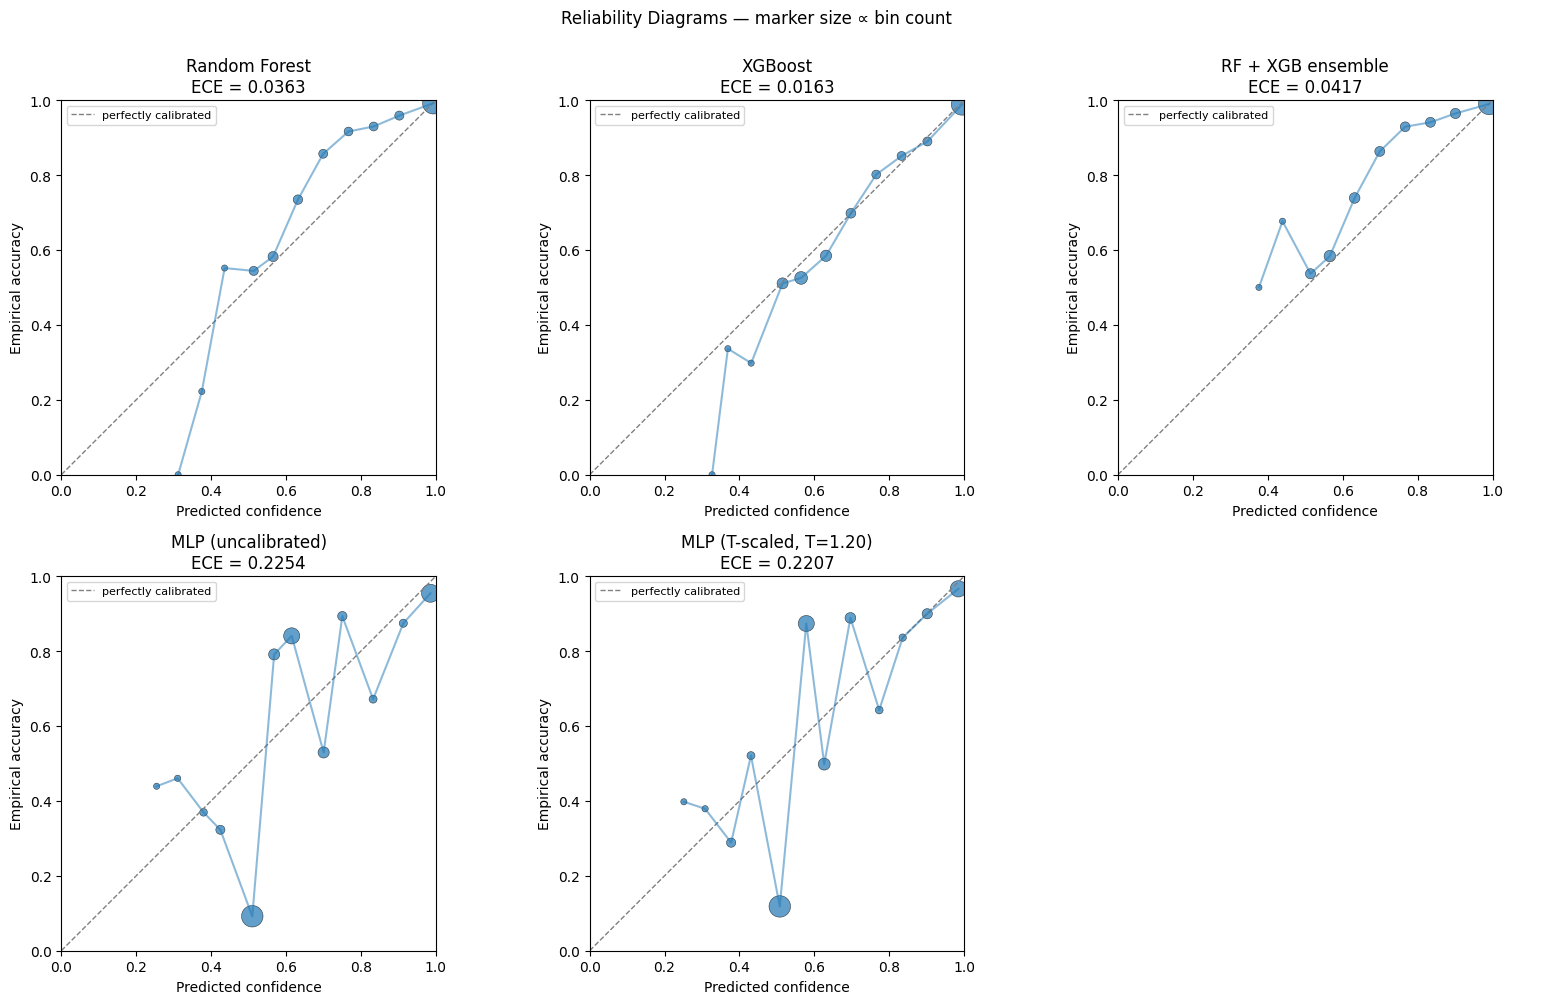

Saved: results/calibration_reliability.png  and  models/mlp_temperature.npy


In [20]:
# ─────────────────────────────────────────────────────────────────────
# CELL 17 — Probability calibration analysis (ECE + reliability diagrams)
#           and temperature scaling for the MLP
#
# Discrimination (F1) and calibration (are the confidences trustworthy?) are
# different properties. A model can rank flows well yet be badly over-/under-
# confident. For an IDS this matters: an analyst triaging by alert confidence
# needs "90% confident" flows to actually be right ~90% of the time.
#
# We measure Expected Calibration Error (ECE, 15 bins on max-class confidence)
# and draw reliability diagrams for RF, XGBoost and the MLP. Neural nets are
# the classic offender (Guo et al. 2017), so we also fit a single temperature
# T on the VALIDATION logits (minimising NLL) and rescale the MLP's logits by
# 1/T. NOTE: temperature scaling is monotonic — it does NOT change the argmax,
# so accuracy/F1 are unchanged; it only makes the probabilities trustworthy.
# ─────────────────────────────────────────────────────────────────────
import numpy as np, joblib, torch
import matplotlib.pyplot as plt

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)

N_BINS = 15

def compute_ece(proba, y_true, n_bins=N_BINS):
    """Multiclass ECE on top-1 confidence + per-bin (conf, acc, count)."""
    conf = proba.max(axis=1)
    pred = proba.argmax(axis=1)
    correct = (pred == y_true).astype(float)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    b_conf = np.full(n_bins, np.nan)
    b_acc  = np.full(n_bins, np.nan)
    b_cnt  = np.zeros(n_bins, dtype=int)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = edges[i], edges[i + 1]
        m = (conf >= lo) & (conf <= hi) if i == n_bins - 1 else (conf >= lo) & (conf < hi)
        cnt = int(m.sum())
        if cnt:
            b_conf[i] = conf[m].mean()
            b_acc[i]  = correct[m].mean()
            b_cnt[i]  = cnt
            ece += (cnt / len(conf)) * abs(b_acc[i] - b_conf[i])
    return ece, b_conf, b_acc, b_cnt

def _softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

# ── Recover MLP (rebuild from checkpoint if not in memory) ───────────
try:
    mlp
except NameError:
    mlp = MLP(X_test.shape[1], len(le.classes_)).to(device)
    mlp.load_state_dict(torch.load('models/mlp.pth', weights_only=True))
mlp.eval()

def _mlp_logits(X_np, batch=4096):
    Xt = torch.from_numpy(X_np.astype(np.float32, copy=False)).to(device)
    out = []
    with torch.no_grad():
        for s in range(0, len(Xt), batch):
            out.append(mlp(Xt[s:s + batch]).cpu().numpy())
    return np.concatenate(out)

print('Computing MLP logits (val + test)...')
val_logits  = _mlp_logits(X_val)
test_logits = _mlp_logits(X_test)

# ── Fit temperature T on val NLL ─────────────────────────────────────
_idx_val = np.arange(len(y_val))
def _val_nll(T):
    p = _softmax(val_logits / T)
    return -np.log(p[_idx_val, y_val] + 1e-12).mean()

# Coarse-to-fine grid search (pure numpy — no external optimiser dependency)
_coarse = np.linspace(0.5, 5.0, 46)                        # step 0.10
_t0     = float(min(_coarse, key=_val_nll))
_fine   = np.linspace(max(0.5, _t0 - 0.1), _t0 + 0.1, 21)  # step 0.01
T_opt   = float(min(_fine, key=_val_nll))
np.save('models/mlp_temperature.npy', np.array([T_opt]))
print(f'Fitted temperature T = {T_opt:.3f}  '
      f'(val NLL {_val_nll(1.0):.4f} -> {_val_nll(T_opt):.4f})')

mlp_proba_uncal = _softmax(test_logits)
mlp_proba_temp  = _softmax(test_logits / T_opt)

# ── RF / XGB test probabilities (reload if not in memory) ────────────
try:    _tp_rf = test_proba_rf
except NameError: _tp_rf = joblib.load('models/random_forest.pkl').predict_proba(X_test)
try:    _tp_xgb = test_proba_xgb
except NameError: _tp_xgb = joblib.load('models/xgboost.pkl').predict_proba(X_test)
# Ensemble = mean of RF & XGB probs (reuse cell 16 result if present)
try:    _tp_ens = test_proba_ens
except NameError: _tp_ens = 0.5 * _tp_rf + 0.5 * _tp_xgb

panels = [
    ('Random Forest',              _tp_rf),
    ('XGBoost',                    _tp_xgb),
    ('RF + XGB ensemble',          _tp_ens),
    ('MLP (uncalibrated)',         mlp_proba_uncal),
    (f'MLP (T-scaled, T={T_opt:.2f})', mlp_proba_temp),
]

# ── ECE table ────────────────────────────────────────────────────────
print('\n' + '=' * 46)
print(f"{'Model':<30}{'ECE':>10}")
print('=' * 46)
results_ece = {}
for name, proba in panels:
    ece, *_ = compute_ece(proba, y_test)
    results_ece[name] = ece
    print(f'  {name:<28}{ece:>10.4f}')
print('=' * 46)
print(f'  MLP ECE reduction: '
      f'{results_ece["MLP (uncalibrated)"]:.4f} -> '
      f'{results_ece[f"MLP (T-scaled, T={T_opt:.2f})"]:.4f}')

# ── Reliability diagrams (2x2) ───────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
_axflat = axes.ravel()
for _ax in _axflat[len(panels):]:
    _ax.axis('off')
for ax, (name, proba) in zip(_axflat, panels):
    ece, b_conf, b_acc, b_cnt = compute_ece(proba, y_test)
    ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1, label='perfectly calibrated')
    m = b_cnt > 0
    sizes = 20 + 220 * (b_cnt[m] / b_cnt.max())
    ax.scatter(b_conf[m], b_acc[m], s=sizes, alpha=0.7, edgecolor='k', linewidth=0.4)
    ax.plot(b_conf[m], b_acc[m], '-', alpha=0.5)
    ax.set_title(f'{name}\nECE = {ece:.4f}')
    ax.set_xlabel('Predicted confidence'); ax.set_ylabel('Empirical accuracy')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(loc='upper left', fontsize=8)
    ax.set_aspect('equal')
plt.suptitle('Reliability Diagrams — marker size ∝ bin count', y=1.0)
plt.tight_layout()
plt.savefig('results/calibration_reliability.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: results/calibration_reliability.png  and  models/mlp_temperature.npy')


In [21]:
# ─────────────────────────────────────────────────────────────────────
# CELL 18 — Comprehensive calibration metrics (imbalance-aware)
#
# Top-label ECE (cell 17) is dominated by the ~83% Benign majority, so it
# understates mis-calibration on the attack ALERTS a SOC analyst triages.
# This cell reports five complementary, citeable calibration metrics:
#   • ECE       — top-label Expected Calibration Error (Guo et al. 2017).
#   • Atk-ECE   — top-label ECE over flows PREDICTED as an attack only.
#   • CW-ECE    — classwise (one-vs-rest) ECE, macro-averaged over all 15
#                 classes so rare attacks count equally (Nixon et al. 2019).
#   • MCE       — Maximum Calibration Error: worst single-bin gap.
#   • Brier     — multiclass Brier score (mean squared prob. error; lower
#                 = better, combines calibration + refinement).
# Reuses panels / compute_ece / N_BINS / y_test / le from cell 17.
# ─────────────────────────────────────────────────────────────────────
import numpy as np

try:
    panels, compute_ece, N_BINS, y_test, le
except NameError:
    raise RuntimeError('Run CELL 17 first — this cell reuses its panels/compute_ece.')

BENIGN = int(np.where(le.classes_ == 'Benign')[0][0])
_NC = len(le.classes_)

def attack_ece(proba, y_true, n_bins=N_BINS):
    """Top-label ECE over flows the model PREDICTS as an attack (argmax != Benign)."""
    m = proba.argmax(axis=1) != BENIGN
    if m.sum() == 0:
        return float('nan')
    ece, *_ = compute_ece(proba[m], y_true[m], n_bins)
    return ece

def classwise_ece(proba, y_true, n_bins=N_BINS):
    """Macro one-vs-rest ECE: per-class calibration of P(class=c), averaged over classes."""
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    per_class = np.full(_NC, np.nan)
    N = len(y_true)
    for c in range(_NC):
        p = proba[:, c]; y = (y_true == c).astype(float); ec = 0.0
        for i in range(n_bins):
            lo, hi = edges[i], edges[i + 1]
            mm = (p >= lo) & (p <= hi) if i == n_bins - 1 else (p >= lo) & (p < hi)
            cnt = int(mm.sum())
            if cnt:
                ec += (cnt / N) * abs(y[mm].mean() - p[mm].mean())
        per_class[c] = ec
    return float(np.nanmean(per_class)), per_class

def mce(proba, y_true, n_bins=N_BINS):
    """Maximum Calibration Error: worst |accuracy - confidence| over non-empty bins."""
    _, b_conf, b_acc, b_cnt = compute_ece(proba, y_true, n_bins)
    m = b_cnt > 0
    return float(np.max(np.abs(b_acc[m] - b_conf[m]))) if m.any() else float('nan')

def brier(proba, y_true):
    """Multiclass Brier score: mean over samples of sum_c (p_c - 1[y=c])^2."""
    onehot = np.zeros_like(proba)
    onehot[np.arange(len(y_true)), y_true] = 1.0
    return float(((proba - onehot) ** 2).sum(axis=1).mean())

# ── Metrics table ────────────────────────────────────────────────────
print('\n' + '=' * 80)
print(f"{'Model':<26}{'ECE':>9}{'Atk-ECE':>9}{'CW-ECE':>9}{'MCE':>9}{'Brier':>10}")
print('=' * 80)
classwise_store = {}
for name, proba in panels:
    top, *_       = compute_ece(proba, y_test)
    att           = attack_ece(proba, y_test)
    cw, per_class = classwise_ece(proba, y_test)
    m_ce          = mce(proba, y_test)
    br            = brier(proba, y_test)
    classwise_store[name] = per_class
    print(f'  {name:<24}{top:>9.4f}{att:>9.4f}{cw:>9.4f}{m_ce:>9.4f}{br:>10.4f}')
print('=' * 80)
print('  ECE/Atk-ECE/CW-ECE/MCE: lower = better calibrated. Brier: lower = better'
      ' (calibration + refinement).')

# ── Where miscalibration hides: per-class ECE for the best model (RF) ─
_ref = 'Random Forest'
if _ref in classwise_store:
    pc = classwise_store[_ref]
    order = np.argsort(pc)[::-1][:6]
    print(f'\nPer-class one-vs-rest ECE — {_ref} (6 worst-calibrated classes):')
    for c in order:
        print(f'  {le.classes_[c]:<28}{pc[c]:>10.4f}')



Model                           ECE  Atk-ECE   CW-ECE      MCE     Brier
  Random Forest              0.0363   0.2162   0.0197   0.3120    0.1479
  XGBoost                    0.0163   0.3229   0.0293   0.3269    0.2363
  RF + XGB ensemble          0.0417   0.2253   0.0216   0.2374    0.1584
  MLP (uncalibrated)         0.2254   0.3728   0.0489   0.4179    0.3915
  MLP (T-scaled, T=1.20)     0.2207   0.3684   0.0500   0.3894    0.3928
  ECE/Atk-ECE/CW-ECE/MCE: lower = better calibrated. Brier: lower = better (calibration + refinement).

Per-class one-vs-rest ECE — Random Forest (6 worst-calibrated classes):
  Benign                          0.1465
  Infilteration                   0.1452
  DoS attacks-SlowHTTPTest        0.0012
  FTP-BruteForce                  0.0012
  Brute Force -Web                0.0004
  DoS attacks-Slowloris           0.0004


In [22]:
# ─────────────────────────────────────────────────────────────────────
# CELL 19 — Bootstrap 95% confidence intervals on macro-F1
#
# A single test-set point estimate hides sampling uncertainty — critical for
# the tiny classes (SQL Injection n=13, XSS n=34, BF-Web n=91) whose F1 rests
# on a handful of flows. We use an EXACT multinomial bootstrap over the 15x15
# confusion matrix: resampling test rows with replacement is equivalent to
# drawing the confusion-cell counts from Multinomial(n, cell_probabilities),
# so 2000 resamples of 2.4 M rows run in seconds rather than minutes.
#
#   • Per-model 95% CIs on macro-F1.
#   • PAIRED bootstrap (shared resample via the joint true x pred_A x pred_B
#     contingency) for "is RF significantly better than XGB?" — reports the
#     CI on the difference and P(A > B).
#   • Per-class 95% CIs for the three tiny classes, to caveat their F1s.
# ─────────────────────────────────────────────────────────────────────
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score

B    = 2000
SEED = 42
_NC  = len(le.classes_)
_lab = np.arange(_NC)

_g = globals()
_need = ['y_pred_rf_cal', 'y_pred_xgb_cal', 'y_pred_mlp_cal', 'y_pred_ens_cal']
_missing = [n for n in _need if n not in _g]
if _missing:
    # Rebuild the missing calibrated predictions from saved artifacts on disk
    # (models/*.pkl, models/mlp.pth, models/thresholds_*.npy) — NO retraining.
    # Mirrors _mlp_preds() (cell 13) and the ensemble blend (cell 16).
    import joblib, torch
    print(f'Rebuilding {_missing} from disk (no retraining)...')

    _tp_rf  = _g.get('test_proba_rf')     # reuse if already in memory
    _tp_xgb = _g.get('test_proba_xgb')

    if 'y_pred_rf_cal' in _missing:
        if _tp_rf is None:
            _tp_rf = joblib.load('models/random_forest.pkl').predict_proba(X_test)
        y_pred_rf_cal = predict_calibrated(_tp_rf, np.load('models/thresholds_rf.npy'))

    if 'y_pred_xgb_cal' in _missing:
        if _tp_xgb is None:
            _tp_xgb = joblib.load('models/xgboost.pkl').predict_proba(X_test)
        y_pred_xgb_cal = predict_calibrated(_tp_xgb, np.load('models/thresholds_xgb.npy'))

    if 'y_pred_mlp_cal' in _missing:
        _mlp = MLP(X_test.shape[1], len(le.classes_)).to(device)   # class from CELL 6b
        _mlp.load_state_dict(torch.load('models/mlp.pth', weights_only=True))
        _mlp.eval()
        _Xt = torch.from_numpy(X_test.astype(np.float32, copy=False)).to(device)
        with torch.no_grad():
            _tp_mlp = torch.softmax(_mlp(_Xt), dim=1).cpu().numpy()
        y_pred_mlp_cal = predict_calibrated(_tp_mlp, np.load('models/thresholds_mlp.npy'))

    if 'y_pred_ens_cal' in _missing:
        if _tp_rf is None:
            _tp_rf = joblib.load('models/random_forest.pkl').predict_proba(X_test)
        if _tp_xgb is None:
            _tp_xgb = joblib.load('models/xgboost.pkl').predict_proba(X_test)
        _w = float(np.load('models/ensemble_weight.npy')[0])
        _tp_ens = _w * _tp_rf + (1 - _w) * _tp_xgb
        y_pred_ens_cal = predict_calibrated(_tp_ens, np.load('models/thresholds_ensemble.npy'))

    print(f'Recovered from disk: {_missing}')

def _macro_f1_from_cm(cm):
    """Macro-F1 (zero_division=0) from confusion matrix/matrices [..., true, pred]."""
    tp = np.einsum('...ii->...i', cm)
    fp = cm.sum(axis=-2) - tp
    fn = cm.sum(axis=-1) - tp
    with np.errstate(invalid='ignore', divide='ignore'):
        prec = np.where(tp + fp > 0, tp / (tp + fp), 0.0)
        rec  = np.where(tp + fn > 0, tp / (tp + fn), 0.0)
        f1   = np.where(prec + rec > 0, 2 * prec * rec / (prec + rec), 0.0)
    return f1.mean(axis=-1), f1

def boot_model(y_true, y_pred, B=B, seed=SEED):
    cm = confusion_matrix(y_true, y_pred, labels=_lab).astype(float)
    n  = int(cm.sum())
    draws = np.random.default_rng(seed).multinomial(n, (cm / n).ravel(), size=B)
    draws = draws.reshape(B, _NC, _NC).astype(float)
    macro, perclass = _macro_f1_from_cm(draws)          # (B,), (B, NC)
    point, point_pc = _macro_f1_from_cm(cm)             # scalar, (NC,)
    return point, macro, point_pc, perclass

def boot_paired(y_true, y_a, y_b, B=B, seed=SEED):
    idx = (y_true.astype(np.int64) * _NC + y_a.astype(np.int64)) * _NC + y_b.astype(np.int64)
    joint = np.bincount(idx, minlength=_NC ** 3).astype(float)
    n = int(joint.sum())
    draws = np.random.default_rng(seed).multinomial(n, joint / n, size=B)
    draws = draws.reshape(B, _NC, _NC, _NC).astype(float)   # [B, true, a, b]
    fa, _ = _macro_f1_from_cm(draws.sum(axis=3))            # collapse b -> cm_a[true, a]
    fb, _ = _macro_f1_from_cm(draws.sum(axis=2))            # collapse a -> cm_b[true, b]
    return fa - fb

models = {
    'RF  (calibrated)':        y_pred_rf_cal,
    'XGB (calibrated)':        y_pred_xgb_cal,
    'MLP (calibrated)':        y_pred_mlp_cal,
    'Ensemble (RF+XGB)':       y_pred_ens_cal,
}

# ── Per-model macro-F1 with 95% CI ───────────────────────────────────
print('=' * 66)
print(f"{'Model':<22}{'Macro-F1':>10}{'95% CI':>24}")
print('=' * 66)
_pc_store = {}
for name, yp in models.items():
    point, macro, _, perclass = boot_model(y_test, yp)
    lo, hi = np.percentile(macro, [2.5, 97.5])
    _pc_store[name] = perclass
    print(f'  {name:<20}{point:>10.4f}   [{lo:.4f}, {hi:.4f}]  (±{(hi-lo)/2:.4f})')
print('=' * 66)

# ── Paired significance tests ────────────────────────────────────────
def _report_pair(a_name, b_name, y_a, y_b):
    d = boot_paired(y_test, y_a, y_b)
    lo, hi = np.percentile(d, [2.5, 97.5])
    p_better = float((d > 0).mean())
    sig = 'YES (CI excludes 0)' if (lo > 0 or hi < 0) else 'no (CI spans 0)'
    print(f'  {a_name} − {b_name}: '
          f'Δmacro-F1 = {d.mean():+.4f}  [{lo:+.4f}, {hi:+.4f}]  '
          f'P({a_name}>{b_name})={p_better:.3f}  → significant: {sig}')

print('\nPaired bootstrap (same resampled rows for both models):')
_report_pair('RF', 'XGB', y_pred_rf_cal, y_pred_xgb_cal)
_report_pair('Ensemble', 'RF', y_pred_ens_cal, y_pred_rf_cal)
_report_pair('Ensemble', 'XGB', y_pred_ens_cal, y_pred_xgb_cal)

# ── Per-class 95% CIs for the tiny (low-support) classes ─────────────
_tiny = ['SQL Injection', 'Brute Force -Web', 'Brute Force -XSS']
print('\nPer-class F1 95% CIs — RF (illustrating tiny-class uncertainty):')
print(f"  {'Class':<20}{'support':>9}{'F1':>8}{'95% CI':>22}")
_rf_pc = _pc_store['RF  (calibrated)']
_, _, _rf_point_pc, _rf_boot_pc = boot_model(y_test, y_pred_rf_cal)
for cname in _tiny:
    c = int(np.where(le.classes_ == cname)[0][0])
    sup = int((y_test == c).sum())
    lo, hi = np.percentile(_rf_boot_pc[:, c], [2.5, 97.5])
    print(f'  {cname:<20}{sup:>9}{_rf_point_pc[c]:>8.3f}   [{lo:.3f}, {hi:.3f}]')
print('\n(A CI spanning much of [0,1] means that class F1 is essentially noise.)')


Model                   Macro-F1                  95% CI


  RF  (calibrated)        0.8360   [0.8145, 0.8521]  (±0.0188)
  XGB (calibrated)        0.7850   [0.7657, 0.8014]  (±0.0178)
  MLP (calibrated)        0.6381   [0.6352, 0.6408]  (±0.0028)
  Ensemble (RF+XGB)       0.8339   [0.8109, 0.8511]  (±0.0201)

Paired bootstrap (same resampled rows for both models):
  RF − XGB: Δmacro-F1 = +0.0505  [+0.0339, +0.0684]  P(RF>XGB)=1.000  → significant: YES (CI excludes 0)
  Ensemble − RF: Δmacro-F1 = -0.0022  [-0.0171, +0.0121]  P(Ensemble>RF)=0.399  → significant: no (CI spans 0)
  Ensemble − XGB: Δmacro-F1 = +0.0487  [+0.0380, +0.0603]  P(Ensemble>XGB)=1.000  → significant: YES (CI excludes 0)

Per-class F1 95% CIs — RF (illustrating tiny-class uncertainty):
  Class                 support      F1                95% CI
  SQL Injection              13   0.667   [0.375, 0.857]
  Brute Force -Web           91   0.689   [0.606, 0.761]
  Brute Force -XSS           34   0.714   [0.581, 0.822]

(A CI spanning much of [0,1] means that class F1 is essent